# Part 2 — From a Bigram Model to a Working Transformer

### Build it, watch it fail, then fix it with one idea

<a href="https://colab.research.google.com/github/YOUR_USERNAME/transformer-from-scratch/blob/main/notebooks/02_bigram_to_transformer.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

In Part 1 we turned text into integers. Now we build a model that predicts the next one.

The plan is deliberately incremental:

1. **A bigram model** — the simplest language model that exists. It will produce garbage, and the *specific way* it fails tells us exactly what is missing.
2. **One self-attention head** — the fix. We will first verify it by hand on a two-word example, then scale it up.
3. **A small GPT** — multi-head attention, feed-forward layers, residual connections, stacked blocks. Around 0.8M parameters, trainable in a few minutes.

> **Tip:** in Colab, go to *Runtime → Change runtime type → T4 GPU*. It runs on CPU too, just slower.

In [1]:
import torch, torch.nn as nn, urllib.request, os, math, time
from torch.nn import functional as F

torch.manual_seed(1337)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch:", torch.__version__)

device: cpu | torch: 2.13.0


## 0. Data and tokenizer

Character-level, exactly as in Part 1. Small enough that every integer in this notebook is something you can inspect by eye.

In [2]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists("input.txt"):
    urllib.request.urlretrieve(URL, "input.txt")
text = open("input.txt").read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encode = lambda s: [stoi[ch] for ch in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print(f"characters : {len(text):,}")
print(f"vocab size : {vocab_size}")
print(f"train/val  : {len(train_data):,} / {len(val_data):,}")

characters : 1,115,394
vocab size : 65
train/val  : 1,003,854 / 111,540


In [3]:
block_size = 64    # how many characters of context the model can see
batch_size = 32

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])   # y is x shifted by one
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("inputs :", xb.shape)
print("targets:", yb.shape, "(the same text, shifted one character left)\n")
print("context ->", repr(decode(xb[0, :20].tolist())))
print("target  ->", repr(decode(yb[0, :20].tolist())))

inputs : torch.Size([32, 64])
targets: torch.Size([32, 64]) (the same text, shifted one character left)

context -> ' both parts\nThan see'
target  -> 'both parts\nThan seek'


In [4]:
@torch.no_grad()
def estimate_loss(model, iters=100):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(iters)
        for k in range(iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = round(losses.mean().item(), 4)
    model.train()
    return out

def train(model, steps, lr):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    t0 = time.time()
    for step in range(steps):
        xb, yb = get_batch("train")
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        if step % (steps // 5) == 0:
            print(f"  step {step:5d} | loss {loss.item():.4f}")
    print(f"  done in {time.time()-t0:.0f}s ->", estimate_loss(model))

---

## 1. The bigram model

The simplest possible language model. To predict the next character, look **only at the current character** — everything before it is discarded.

The whole model is one lookup table of shape `vocab_size × vocab_size`. Row *i* holds the scores for "what tends to follow character *i*". After seeing `q`, it should learn to put mass on `u`.

There is no context, no memory, no architecture. Just a table of counts, learned by gradient descent.

In [5]:
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)          # (B, T, vocab_size)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            probs = F.softmax(logits[:, -1, :], dim=-1)   # only the last position matters
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

bigram = BigramLanguageModel().to(device)
print("parameters:", sum(p.numel() for p in bigram.parameters()))

parameters: 4225


In [6]:
print("BEFORE training (random weights):")
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(bigram.generate(context, 150)[0].tolist()))

BEFORE training (random weights):

JLg,3D&OM .3YCjfolRwqXaDyttW!GmaUT-IIvuZV?sYfjzUvTQ3RwL ?etyLeg.COHW
Ri$ELkJMXpBEX;-G&Orl!bcH ;cq.z,rbyQZoN:QVT:cVOtkTLhuMYe-gqGhTxDlqYBkLDJnAsLJOVeJY


In [7]:
print("training bigram...")
train(bigram, steps=3000, lr=1e-2)

training bigram...
  step     0 | loss 4.7821
  step   600 | loss 2.5083
  step  1200 | loss 2.4636
  step  1800 | loss 2.4330
  step  2400 | loss 2.4723
  done in 2s -> {'train': 2.4579, 'val': 2.4813}


In [8]:
print("AFTER training:\n")
print(decode(bigram.generate(context, 400)[0].tolist()))

AFTER training:


Thak m s' tize t,
Tof hat IUSI thagore fan
Sws se blco t be ss s, te; ttNRLer'se avG cheare coms F whongre incty tugthods lll olveverd s:
HABouIO: ILABERIShe
ADULAn'st ly so ar knelarormay. me,
F f fo fediare, pand? mess iksey sereran rayir, arve
Yomy.

I fink geY a ms chantr s ha hacavendaney.
Whivethillarf d t wictheckieary avemeaver
ARI pinto be acowhan! g. tt pemou piaris
's, homind t hithier 


### Read that output carefully — the failure is informative

It is not random noise any more. Character *pairs* are plausible: `th`, `ou`, `qu`, and the loss dropped meaningfully. It even learned Shakespeare's formatting habit of `NAME:` followed by a newline.

But there are no words, and certainly no sentences. And the reason is exactly the design: **when generating character 200, the model looks at character 199 and nothing else.** Everything before is thrown away.

To write `"the river bank"`, a model needs to still be holding onto `river` by the time it reaches `bank`. Our bigram model structurally cannot.

**What we need is a way for each position to look back at every previous position and pull in what matters.**

That is self-attention.

---

## 2. Self-attention, verified by hand

Before touching real data, let's confirm the mechanism on a two-word example with numbers small enough to check on paper.

Sentence: **"river bank"**. We want `bank` to absorb meaning from `river`.

Each token produces three vectors:

- **Query** — what I am looking for
- **Key** — what I offer
- **Value** — what I hand over if selected

Compare each Query against every Key with a dot product, softmax the scores into weights, then take the weighted sum of the Values.

In [9]:
# 2-dimensional embeddings so every number is inspectable
x_river = torch.tensor([1., 0.])
x_bank  = torch.tensor([0., 1.])

# Hand-picked weight matrices (in a real model these are LEARNED)
W_Q = torch.tensor([[0., 1.], [1., 0.]])
W_K = torch.tensor([[1., 0.], [0., 1.]])
W_V = torch.tensor([[2., 0.], [0., 1.]])

q_bank  = x_bank  @ W_Q
k_river = x_river @ W_K
k_bank  = x_bank  @ W_K
v_river = x_river @ W_V
v_bank  = x_bank  @ W_V

print("q_bank  =", q_bank.tolist())
print("k_river =", k_river.tolist(), " k_bank =", k_bank.tolist())
print("v_river =", v_river.tolist(), " v_bank =", v_bank.tolist())

q_bank  = [1.0, 0.0]
k_river = [1.0, 0.0]  k_bank = [0.0, 1.0]
v_river = [2.0, 0.0]  v_bank = [0.0, 1.0]


In [10]:
d_k = 2

scores = torch.tensor([q_bank @ k_river, q_bank @ k_bank])
print("raw scores      :", scores.tolist())

scaled = scores / math.sqrt(d_k)
print("scaled by sqrt(d):", [round(v, 4) for v in scaled.tolist()])

weights = F.softmax(scaled, dim=-1)
print("attention weights:", [round(v, 4) for v in weights.tolist()])
print(f"  -> 'bank' draws {weights[0]:.0%} from 'river' and {weights[1]:.0%} from itself")

output = weights[0] * v_river + weights[1] * v_bank
print("\ninput  x_bank :", x_bank.tolist())
print("output        :", [round(v, 4) for v in output.tolist()])

raw scores      : [1.0, 0.0]
scaled by sqrt(d): [0.7071, 0.0]
attention weights: [0.6698, 0.3302]
  -> 'bank' draws 67% from 'river' and 33% from itself

input  x_bank : [0.0, 1.0]
output        : [1.3395, 0.3302]


The token `bank` entered as `[0, 1]` and left as roughly `[1.34, 0.33]` — now dominated by the `river` direction. **The word has been rewritten in terms of its context.** That is the entire idea.

Two details worth understanding:

- **Why divide by √d?** Dot products of *d*-dimensional vectors grow with *d*. Large values push softmax toward a one-hot distribution, where gradients vanish. Dividing by √d keeps the variance stable regardless of head size.
- **Why Query, Key *and* Value?** Separating "what I search for" from "what I hand over" lets a token attend based on one criterion while contributing entirely different information. Collapsing them would lose that flexibility.

Now the same computation, vectorised over a whole batch.

In [11]:
B, T, C = 4, 8, 32
x = torch.randn(B, T, C)
head_size = 16

key   = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k, q, v = key(x), query(x), value(x)
w = q @ k.transpose(-2, -1) * head_size**-0.5     # (B, T, T)
print("attention matrix:", w.shape, "- every token scored against every token")

attention matrix: torch.Size([4, 8, 8]) - every token scored against every token


### The causal mask

There is a problem. That matrix lets position 3 attend to position 7 — a token from the *future*. During training the whole sequence is present at once, so the model would simply read off the answer and learn nothing useful.

The fix is to set all future positions to `-inf` before the softmax, which makes their weight exactly zero. Lower-triangular mask, hence `tril`.

In [12]:
tril = torch.tril(torch.ones(T, T))
w_masked = w.masked_fill(tril == 0, float("-inf"))
w_masked = F.softmax(w_masked, dim=-1)

print("attention weights for the first sequence (rows = query position):\n")
print(w_masked[0].round(decimals=2))

attention weights for the first sequence (rows = query position):

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6100, 0.3900, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2300, 0.2800, 0.4900, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2100, 0.2700, 0.2600, 0.2700, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1700, 0.2300, 0.2500, 0.1900, 0.1500, 0.0000, 0.0000, 0.0000],
        [0.1900, 0.1400, 0.1700, 0.2000, 0.1200, 0.1800, 0.0000, 0.0000],
        [0.1000, 0.1100, 0.2300, 0.1600, 0.1500, 0.0900, 0.1600, 0.0000],
        [0.1500, 0.1200, 0.0700, 0.1400, 0.1200, 0.1200, 0.1800, 0.1000]],
       grad_fn=<RoundBackward1>)


Read the triangle: row 0 can only attend to itself (weight 1.00). Row 1 splits across two positions. Row 7 distributes across all eight. Every row sums to 1, and the upper triangle is exactly zero. **The past is visible; the future is not.**

---

## 3. Assembling a transformer

We now have the one non-obvious component. The rest is standard neural network construction.

- **Multi-head attention** — run several attention heads in parallel with smaller dimensions each, then concatenate. One head can track subject–verb agreement while another tracks quotation marks. One head has to compromise; eight do not.
- **Feed-forward network** — attention *moves information between* positions; the FFN *thinks about* it at each position independently. It holds roughly two-thirds of a block's parameters and is where much of the model's knowledge is believed to live.
- **Residual connections** — `x + sublayer(x)` gives gradients an uninterrupted path back through depth. Without them, deep stacks do not train.
- **Layer normalisation** — normalises each token's features, keeping activations well-scaled. We apply it *before* each sublayer (pre-norm), which is what modern models do.

In [13]:
n_embd   = 128     # embedding dimension
n_head   = 4       # attention heads per block
n_layer  = 4       # stacked transformer blocks
dropout  = 0.1

class Head(nn.Module):
    # One head of causal self-attention
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q, v = self.key(x), self.query(x), self.value(x)
        w = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5      # score
        w = w.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # mask the future
        w = self.dropout(F.softmax(w, dim=-1))               # normalise
        return w @ v                                          # blend the values

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj  = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),   # expand
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),   # project back
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    # Communication (attention) followed by computation (feed-forward)
    def __init__(self):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward()
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))     # residual around attention
        x = x + self.ffwd(self.ln2(x))   # residual around feed-forward
        return x

### Positional encoding

One last gap. Attention is a weighted sum, and addition is commutative — so on its own it is **completely blind to word order**. `"dog bites man"` and `"man bites dog"` would produce identical outputs.

The fix here is a second embedding table indexed by *position*, added to the token embedding. GPT-2 does exactly this and learns it during training. (Modern models often use rotary embeddings instead, but the purpose is the same.)

In [14]:
class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f   = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embedding(idx)                                    # (B,T,n_embd)
        pos = self.position_embedding(torch.arange(T, device=idx.device))  # (T,n_embd)
        x = tok + pos
        x = self.ln_f(self.blocks(x))
        logits = self.lm_head(x)                                           # (B,T,vocab)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]          # never exceed the context window
            logits, _ = self(idx_cond)
            probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

model = MiniGPT().to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

parameters: 0.82M


In [15]:
# ~2-4 min on a Colab T4, noticeably longer on CPU.
print("training MiniGPT...")
train(model, steps=4000, lr=3e-4)

training MiniGPT...
  step     0 | loss 4.2824
  step   800 | loss 2.1491
  step  1600 | loss 1.9148
  step  2400 | loss 1.7036
  step  3200 | loss 1.7770
  done in 171s -> {'train': 1.588, 'val': 1.7615}


In [16]:
print(decode(model.generate(context, 800)[0].tolist()))


QUEEN, tirmane, helar:
You be call mare weops death, other. 
LUCIO:
They, and themselmaley that orw thus opent.
Give repited my dratus, whole seee,
To reappeross men prown descinenty,
And with where, vantar this mind much matters under there?

GAUM:
Go, me, ware cappreport prouce has a pussits on that
That wirsed should, whiless thus his him'd pusk trabe,
So the o'that the fare thande sounts Lord be in the reaster
And tathinguy, folse treagate? for you well with you;
Andibel shate are his cright.
Proved that, ough's a say not Clan,
Harw for the for wethat in that timalemien pose;
Mower of of my not that over my daight concellower?

Nurse:
Untereshar; if is conword ball now: I--'twalt I wake hop;
Learrad stome the be bushal grish thing's noing
and the dost:
For whost no daughter, look joy o


### Compare that to the bigram output

Still nonsense as literature — it is a 0.8M-parameter model trained for a few minutes on 1 MB of text. But look at what changed:

- Words are mostly real words, spelled consistently
- Speaker labels, colons and line breaks follow Shakespeare's structure
- Punctuation and capitalisation land in plausible places
- Sentence-like shapes persist across many characters

The only structural difference from the bigram model is that each position can now look back at the previous 64 and decide what matters. **That is what attention bought us.**

---

## 4. Looking inside the model

The attention weights are just numbers — we can read them directly and see which characters the model chose to look at.

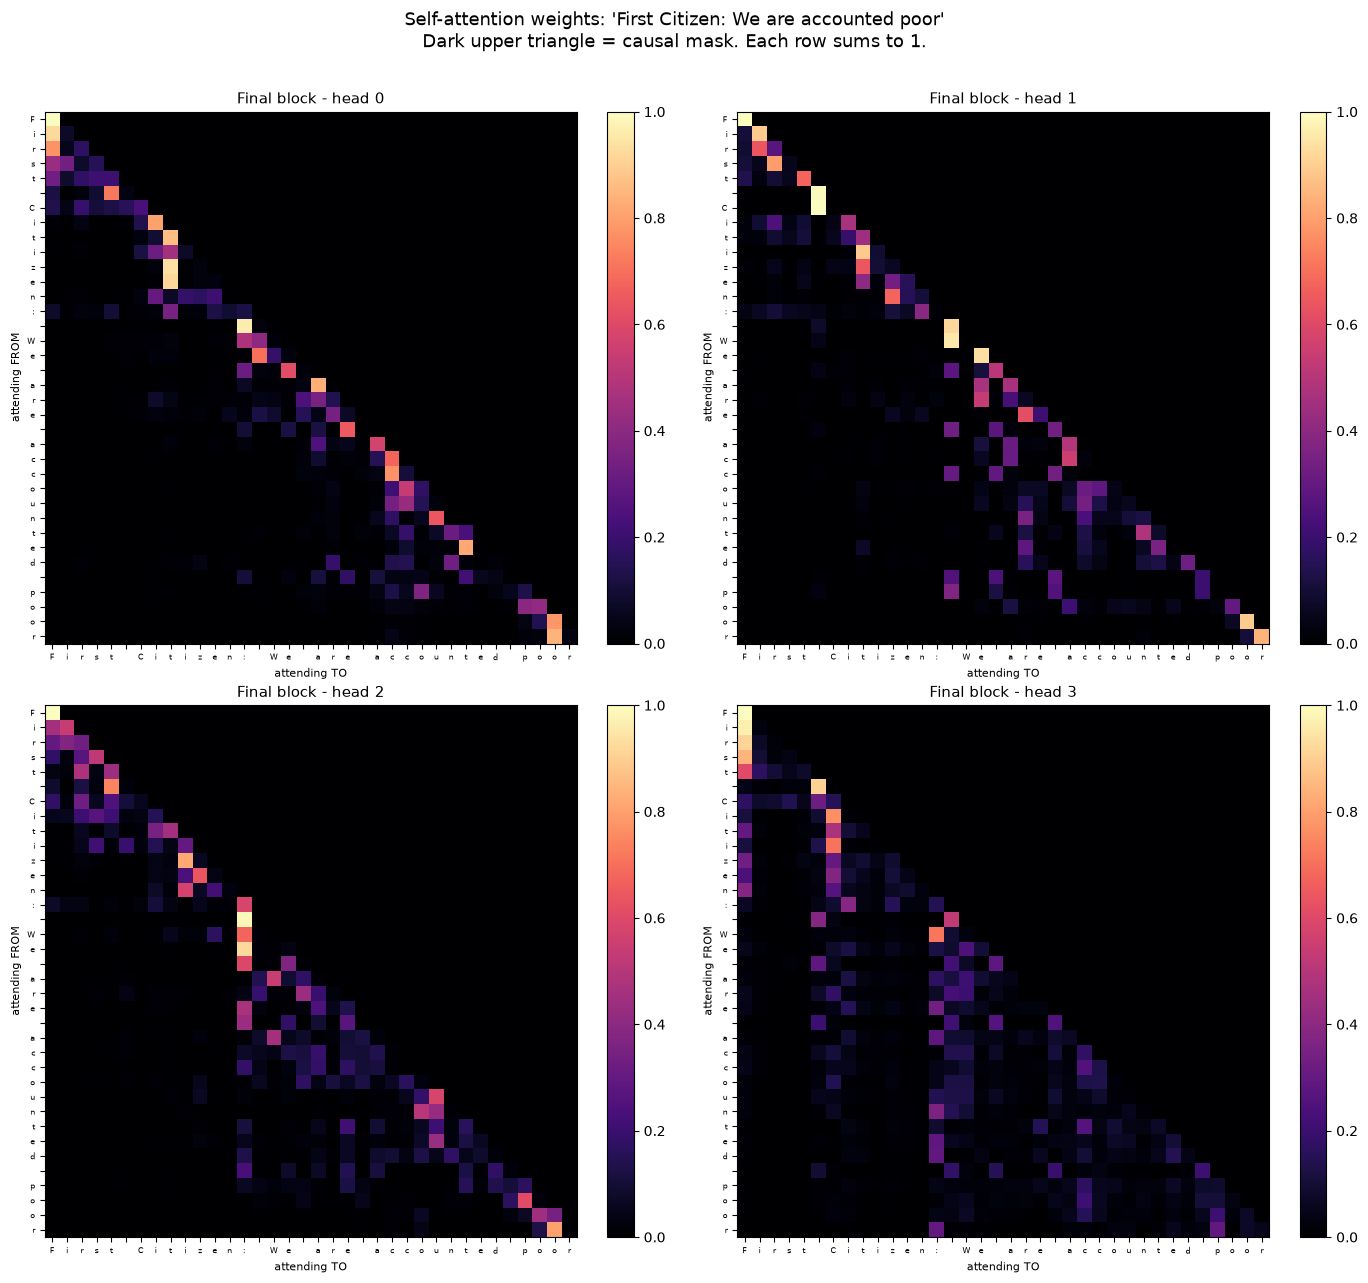

In [17]:
import matplotlib.pyplot as plt

prompt = "First Citizen: We are accounted poor"
ids = torch.tensor([encode(prompt)], device=device)

n_show = len(model.blocks[-1].sa.heads)   # every head in the final block
acts = {}

def make_hook(name):
    def hook(mod, inp, out):
        x = inp[0]
        B, T, C = x.shape
        k, q = mod.key(x), mod.query(x)
        w = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        w = w.masked_fill(mod.tril[:T, :T] == 0, float("-inf"))
        acts[name] = F.softmax(w, dim=-1).detach().cpu()[0]
    return hook

handles = [model.blocks[-1].sa.heads[i].register_forward_hook(make_hook(f"head {i}"))
           for i in range(n_show)]
model.eval()
with torch.no_grad():
    model(ids)
for h in handles:
    h.remove()

labels = list(prompt)
rows = (n_show + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(14, 6.5 * rows))
for ax, (name, w) in zip(axes.flat, acts.items()):
    im = ax.imshow(w, cmap="magma", interpolation="nearest")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=6)
    ax.set_title(f"Final block - {name}", fontsize=11)
    ax.set_xlabel("attending TO", fontsize=8)
    ax.set_ylabel("attending FROM", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
for ax in axes.flat[len(acts):]:
    ax.axis("off")

fig.suptitle(f"Self-attention weights: '{prompt}'\n"
             "Dark upper triangle = causal mask. Each row sums to 1.", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("attention_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# In Colab the file appears in the left-hand file browser (folder icon), or:
#   from google.colab import files; files.download("attention_heatmap.png")

Bright cells are high attention. Two things to look for.

The upper-right triangle of every panel is uniformly dark — that is the causal mask doing its job, and it is a useful sanity check that your masking is correct.

More interesting is that the heads do **not** look alike. Some concentrate near the diagonal, attending mostly to the previous few characters. Others show vertical stripes, where many positions all look back at the same few characters — often the spaces and punctuation that mark structural boundaries in the text. Nobody assigned them these jobs; they divided the labour during training. That division is the entire argument for using more than one head.

---

## 5. From here to GPT-4

Everything above is the real architecture. The differences at production scale are quantitative, not conceptual:

| | This notebook | GPT-3 |
|---|---|---|
| Parameters | ~0.8M | 175B |
| Layers | 4 | 96 |
| Heads | 4 | 96 |
| Embedding dim | 128 | 12,288 |
| Context | 64 characters | 2,048 tokens |
| Tokenizer | 65 characters | ~50k BPE merges |
| Training data | 1 MB | ~500 GB |

Plus engineering that does not change the maths: flash attention, mixed precision, rotary position embeddings, grouped-query attention, and post-training with RLHF to make a raw next-token predictor behave like an assistant.

But the block you built — attend, then think, wrapped in residual connections — is the same block.

## Recap

1. A bigram model fails because it discards context.
2. Self-attention fixes this: Query · Key → softmax → weighted sum of Values.
3. A causal mask stops the model from reading the future.
4. Multiple heads let the model track several relationships at once.
5. Feed-forward layers process what attention gathered.
6. Residual connections and layer norm make depth trainable.
7. Positional embeddings restore the word order attention throws away.

---

### Things worth trying

- Increase `n_layer` and `n_embd` and watch validation loss — where does it start overfitting?
- Set `block_size = 16` and see how much fluency depends on context length.
- Vary `temperature` in `generate()` — 0.5 for cautious output, 1.5 for chaotic.
- Swap in your own text file. Your Slack export, a codebase, song lyrics you have rights to.
- Replace the character tokenizer with SentencePiece from Part 1 and compare.